In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df=pd.read_csv('Data/Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [5]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [8]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [10]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [12]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)
                                               

In [14]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaler =scaler.fit_transform(X_train)
X_test_scaler=scaler.fit_transform(X_test)

In [15]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [17]:
model=Sequential()

In [18]:
model.add(Dense(11,activation='sigmoid',input_dim=11))
model.add(Dense(11,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

c:\Rajeshwari\Udemy Data Science\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11 Inputs
     │
     ▼
Hidden Layer (11 neurons)
     │
     ▼
Hidden Layer (11 neurons)
     │
     ▼
Output (1 neuron)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

Optimizer: Adam

Updates the weights during training. Adam is widely used because it adapts the learning rate and generally converges faster than basic gradient descent.

Loss: Binary Crossentropy

Measures how far the predicted probabilities are from the true labels in a binary classification task.

The training process aims to minimize this loss.

Metric: Accuracy

Reports the percentage of correct predictions.

In [21]:
history=model.fit(X_train_scaler,y_train,validation_split=0.2,verbose=1,batch_size=10,epochs=100)

Epoch 1/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7780 - loss: 0.5166 - val_accuracy: 0.7969 - val_loss: 0.4760
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7958 - loss: 0.4572 - val_accuracy: 0.7962 - val_loss: 0.4426
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8066 - loss: 0.4316 - val_accuracy: 0.8125 - val_loss: 0.4313
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8139 - loss: 0.4246 - val_accuracy: 0.8125 - val_loss: 0.4278
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8166 - loss: 0.4205 - val_accuracy: 0.8163 - val_loss: 0.4247
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8234 - loss: 0.4178 - val_accuracy: 0.8225 - val_loss: 0.4210
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8236 - loss: 0.4138 - val_accuracy: 0.8275 - val_loss: 0.4166
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8280 - loss: 0.4095 - val_accu

Epochs = 100

The model sees the training data 100 times.

Batch Size = 10

Instead of updating weights after all training samples, it updates them after every 10 samples.

Validation Split = 0.2

20% of the training data is used for validation to monitor performance during training.

In [23]:
model.layers[1].get_weights()

[array([[-8.31696570e-01, -6.83529019e-01,  8.67466163e-03,
          6.85194254e-01,  4.50125486e-01,  8.48861694e-01,
         -9.12965536e-02,  1.91849306e-01, -5.65642357e-01,
         -8.64478469e-01, -4.09208596e-01],
        [-4.86820161e-01, -2.01485202e-01,  5.10099471e-01,
          5.00572741e-01,  7.62005329e-01, -1.31636765e-02,
          6.74175501e-01, -5.01574993e-01,  1.69094652e-01,
         -8.18960443e-02,  6.64992183e-02],
        [ 8.42043757e-01,  1.20559454e+00, -1.06043315e+00,
         -1.00284994e+00, -1.14591134e+00, -7.61640549e-01,
         -1.24658656e+00,  6.58375263e-01,  1.19008267e+00,
          1.00226831e+00, -1.05379319e+00],
        [ 1.17067623e+00,  1.29566514e+00, -1.01512265e+00,
         -6.00871384e-01, -9.50968385e-01, -1.00683725e+00,
         -6.82906806e-01,  1.09507203e+00,  1.38074720e+00,
          1.09682131e+00, -6.29739940e-01],
        [-3.08446795e-01, -3.38078946e-01,  8.33386540e-01,
          2.53213525e-01,  1.70406103e-01,  

In [24]:
y_log=model.predict(X_test_scaler)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
y_pred=np.where(y_log>0.5,1,0)

'''Uses a threshold of 0.5:

Probability > 0.5 → Predict 1 (customer churns)
Probability ≤ 0.5 → Predict 0 (customer stays'''

In [26]:
from sklearn.metrics import confusion_matrix,accuracy_score
accuracy_score(y_test,y_pred)

0.861

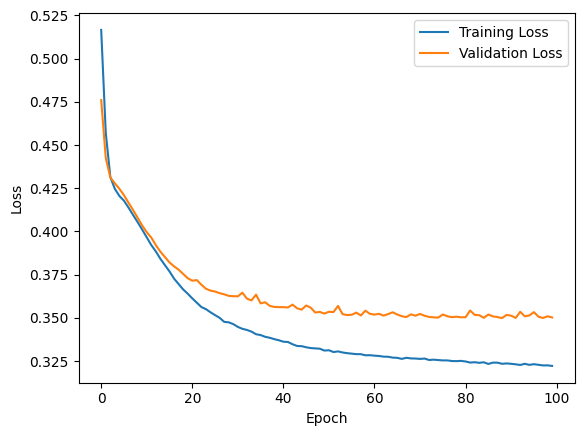

In [29]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

This graph helps diagnose training.

If both training and validation loss decrease together, the model is learning well.
If training loss keeps decreasing but validation loss starts increasing, the model is likely overfitting.
If both losses remain high, the model may be underfitting.

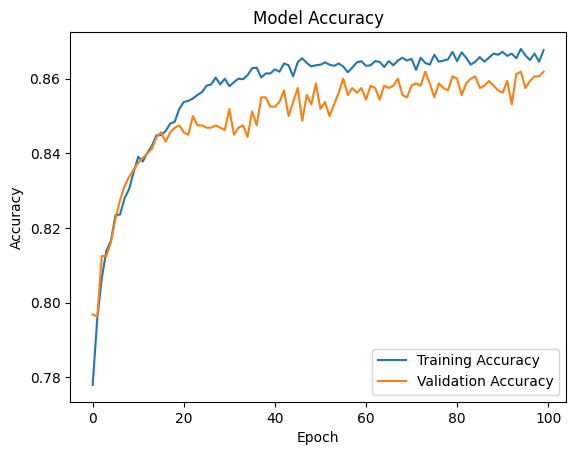

In [30]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.legend()

plt.show()